In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.size": 10,        # default text
    "axes.titlesize": 14,   # title
    "axes.labelsize": 12,   # axis labels
    "xtick.labelsize": 10,  # x tick labels
    "ytick.labelsize": 10,  # y tick labels
    "legend.fontsize": 10
})

result_dir = "/mnt/oss_nanhu100TB/default/zjq/results/SpecFun/result"

In [54]:
task = 'predict' # direct, predict
dataset = "desi-sv1" #desi-sv1, provabgs-v2
# mods = ["sp", "im", "ph", "im+ph", "sp+im", "sp+ph", "sp+im+ph"]
mods = ["sp", "im","im+ph", "sp+im", "sp+ph", "sp+im+ph"]
targets = ["z"]

In [55]:
# store metrics

mask_types = ["zq", "spec_snr_mean", "spec_snr_median"][:1]
cut_ids = range(5)

metrics_dict = {mask_type: { mod: {"cut": [], "mae": [], "r2": [], "rmse": []}for mod in mods} for mask_type in mask_types}

for mask_type in mask_types:
    for i in cut_ids:
        mask = f"{mask_type}_cut{i}"
        for mod in mods:
            # file path
            if "cut0" in mask:
                pred_file = os.path.join(result_dir, f"{dataset}", "predict",f"{dataset}_{mod}_{task}_z.npz")
            elif "zq_cut" in mask:
                pred_file = os.path.join(result_dir, f"{dataset}", "predict", "zq_cut",f"{dataset}_{mod}_{task}_z_{mask}.npz")
            elif "spec_snr" in mask:
                pred_file = os.path.join(result_dir, f"{dataset}", "predict", "spec_snr",f"{dataset}_{mod}_{task}_z_{mask}.npz")
            else:
                raise ValueError(f"Unknown mask type: {mask}")
            data = np.load(pred_file, allow_pickle=True)
            y_true = data["test_true" if task == 'predict' else "z_true"]
            y_pred = data["test_pred" if task == 'predict' else "z_pred"]
            # metrics
            mae = np.mean(np.abs(y_true - y_pred))
            rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
            r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

            metrics_dict[mask_type][mod]["cut"].append(i)
            metrics_dict[mask_type][mod]["mae"].append(mae)
            metrics_dict[mask_type][mod]["rmse"].append(rmse)
            metrics_dict[mask_type][mod]["r2"].append(r2)

/tmp/ipykernel_1667520/445256606.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


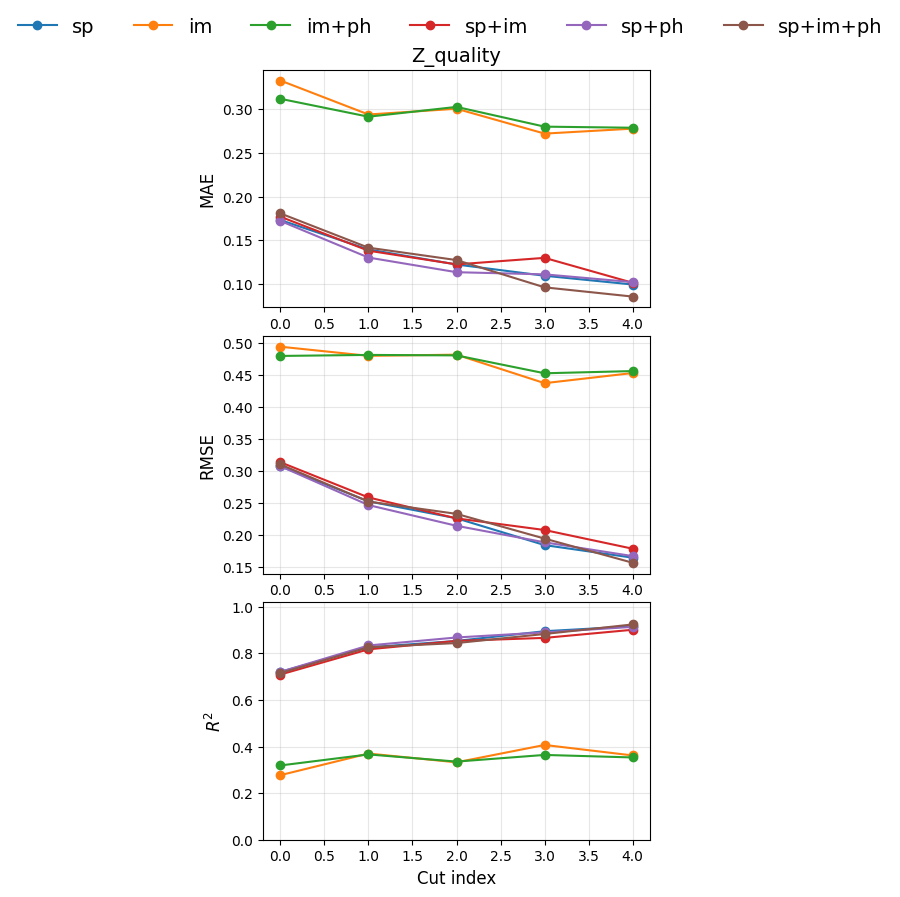

In [56]:
title_map = {
    "zq": "Z_quality",
    "spec_snr_mean": "Spec SNR (mean)",
    "spec_snr_median": "Spec SNR (median)"
}

fig = plt.figure(figsize=(5*len(mask_types), 10))  # taller figure
gs = gridspec.GridSpec(3, len(mask_types), figure=fig, wspace=0.18, hspace=0.12)

for c, mask_type in enumerate(mask_types):
    # ---- MAE row ----
    ax1 = fig.add_subplot(gs[0, c])
    for mod in mods:
        ax1.plot(
            metrics_dict[mask_type][mod]["cut"],
            metrics_dict[mask_type][mod]["mae"],
            marker="o",
            label=mod
        )
    ax1.set_title(title_map.get(mask_type, mask_type))
    if c == 0:
        ax1.set_ylabel("MAE")
    ax1.grid(alpha=0.3)

    # ---- RMSE row ----
    ax_mid = fig.add_subplot(gs[1, c])
    for mod in mods:
        ax_mid.plot(
            metrics_dict[mask_type][mod]["cut"],
            metrics_dict[mask_type][mod]["rmse"],
            marker="o"
        )
    if c == 0:
        ax_mid.set_ylabel("RMSE")
    ax_mid.grid(alpha=0.3)

    # ---- R2 row ----
    ax2 = fig.add_subplot(gs[2, c])
    for mod in mods:
        ax2.plot(
            metrics_dict[mask_type][mod]["cut"],
            metrics_dict[mask_type][mod]["r2"],
            marker="o"
        )
    ax2.set_xlabel("Cut index")
    if c == 0:
        ax2.set_ylabel(r"$R^2$")
    ax2.set_ylim(0, 1.02)
    ax2.grid(alpha=0.3)

# shared legend (only need from first axis)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels,loc="upper center",fontsize=14, bbox_to_anchor=(0.5, 0.95), ncol=len(mods),frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

/tmp/ipykernel_1667520/35342921.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


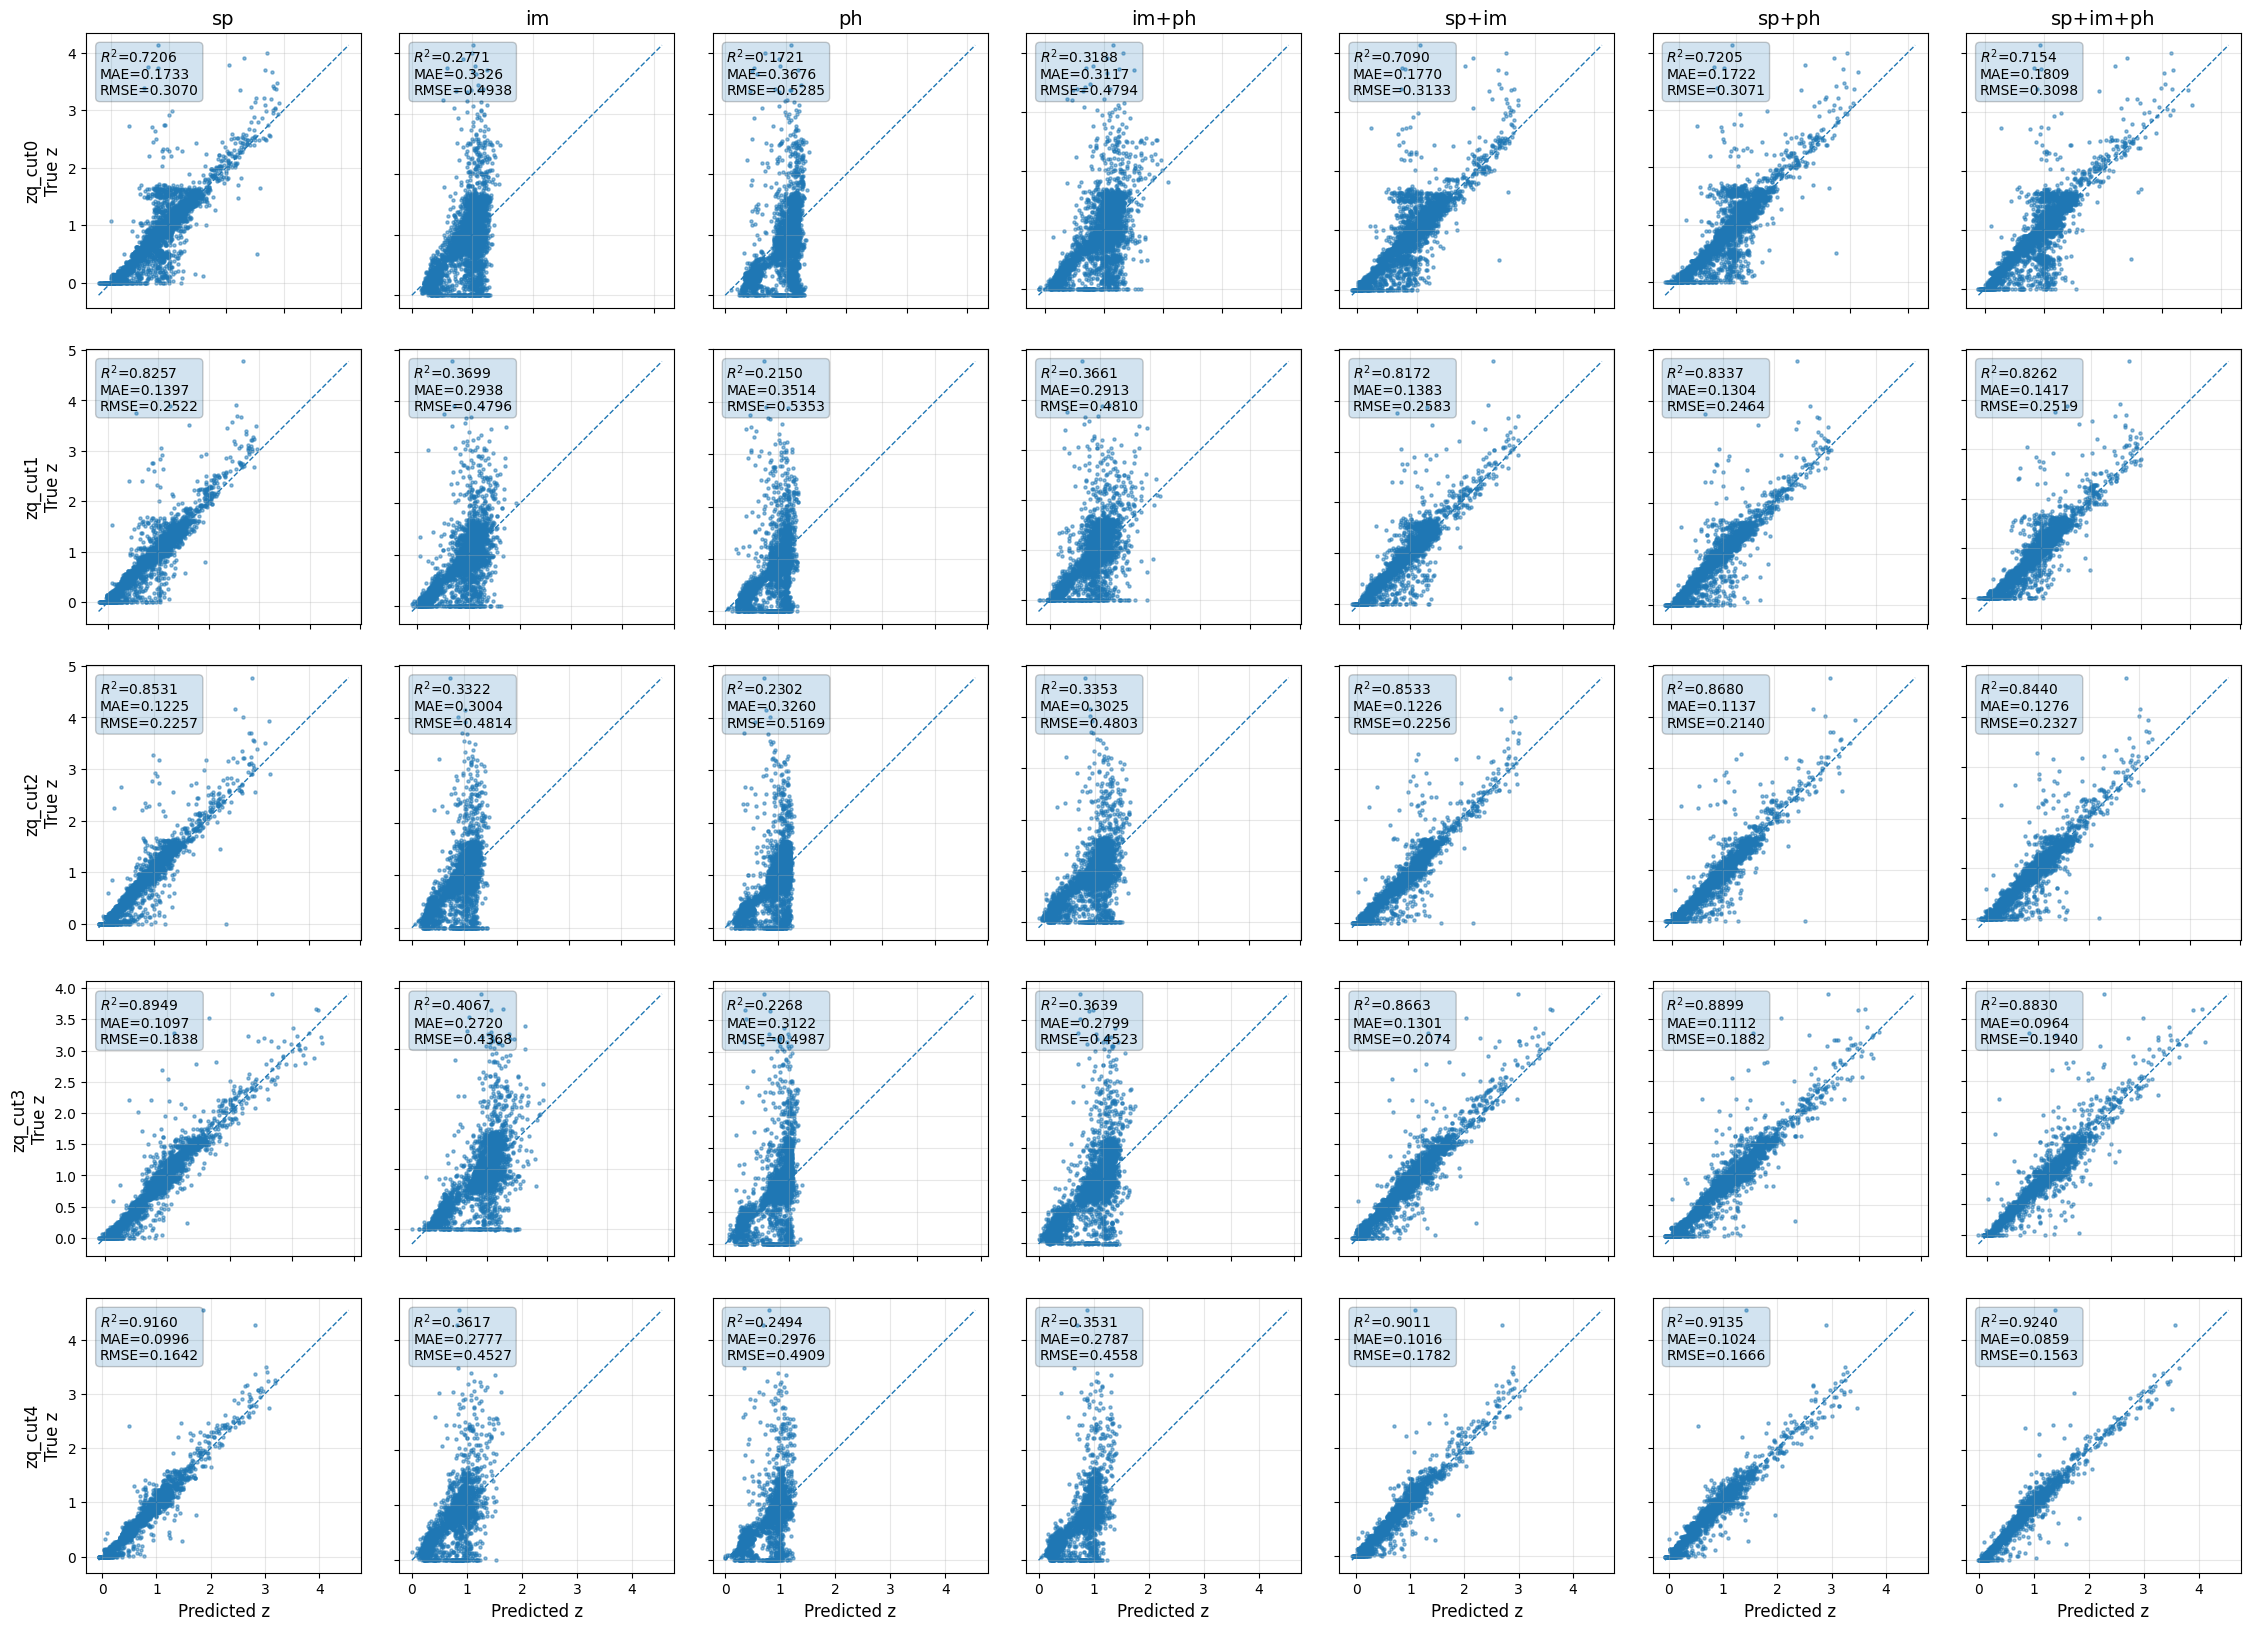

In [9]:
# masks = ["spec_snr_mean_cut0", "spec_snr_mean_cut1", "spec_snr_mean_cut2", "spec_snr_mean_cut3" , "spec_snr_mean_cut4"]
masks = ["zq_cut0", "zq_cut1", "zq_cut2", "zq_cut3" , "zq_cut4"]

n_rows = len(masks)
n_cols = len(mods)

fig = plt.figure(figsize=(4 * n_cols, 4 * n_rows))
gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.08, hspace=0.15)

for r, mask in enumerate(masks):
    for c, mod in enumerate(mods):
        # decide file path
        if "cut0" in mask:
            pred_file = os.path.join(result_dir, f"{dataset}", "predict",f"{dataset}_{mod}_predict_z.npz")
        elif "zq_cut" in mask:
            pred_file = os.path.join(result_dir, f"{dataset}", "predict", "zq_cut",f"{dataset}_{mod}_predict_z_{mask}.npz")
        elif "spec_snr" in mask:
            pred_file = os.path.join(result_dir, f"{dataset}", "predict", "spec_snr",f"{dataset}_{mod}_predict_z_{mask}.npz")
        else:
            raise ValueError(f"Unknown mask type: {mask}")

        data = np.load(pred_file, allow_pickle=True)
        # your new file uses these keys
        y_true = data["test_true"]
        y_pred = data["test_pred"]
        dz = np.abs(y_true - y_pred) / (1 + y_true)

        # metrics
        r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        ax = fig.add_subplot(gs[r, c])
        ax.scatter(y_pred, y_true, s=5, alpha=0.5)
        xmin = min(y_true.min(), y_pred.min())
        xmax = max(y_true.max(), y_pred.max())
        ax.plot([xmin, xmax], [xmin, xmax], "--", linewidth=1)
        ax.set_aspect("equal", adjustable="box")
        if r == 0: ax.set_title(mod)
        if r == n_rows - 1: ax.set_xlabel("Predicted z")
        # y labels only on first col
        if c == 0:
            ax.set_ylabel(f"{mask}\nTrue z")
        else:
            ax.tick_params(labelleft=False)
        if r != n_rows - 1:
            ax.tick_params(labelbottom=False)
        ax.text(
            0.05, 0.95,
            f"$R^2$={r2:.4f}\nMAE={mae:.4f}\nRMSE={rmse:.4f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", alpha=0.2)
        )
        if dataset in ["provabgs-v2"]:
            ax.set_xlim([0, 0.6])
            ax.set_ylim([0, 0.6])
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

NpzFile '/mnt/oss_nanhu100TB/default/zjq/results/SpecFun/result/desi-sv1/predict/spec_snr/desi-sv1_sp+im+ph_predict_z_spec_snr_mean_cut1.npz' with keys: test_true, test_pred, label_names, feature_shape, target_shape